In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command
from langchain_core.messages import BaseMessage,AnyMessage,AIMessage
from langgraph.graph.message import add_messages


In [2]:
load_dotenv()

True

In [3]:
llm=ChatOpenAI(model='gpt-4.1-mini')

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [6]:
def chat_node(state:ChatState):
    decision=interrupt({
        'type':'approval',
        "reason":"Model is about to answer user's question",
        "question":state["messages"][-1].content,
        "instruction":"approve this questionn ? yes/no"
    })
    if decision["approved"]=='no':
        return {"messages":[AIMessage(content="Not approved.")]}

    else:
        response=llm.invoke(state["messages"])
        return{"messages":[response]}



In [8]:
graph=StateGraph(ChatState)
graph.add_node("chat",chat_node)
graph.add_edge(START,"chat")
graph.add_edge("chat",END)
checkpointer=MemorySaver()
app=graph.compile(checkpointer=checkpointer)

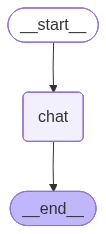

In [9]:
app

In [18]:
# create a thread_id for the convo ad we are using chekcpointer
config={"configurable":{"thread_id":'1234'}}
initial_input={"messages":[("user","explain attention mechanism in transformers")]}
result=app.invoke(initial_input,config)

In [19]:
result

{'messages': [HumanMessage(content='explain attention mechanism in transformers', additional_kwargs={}, response_metadata={}, id='74775135-6deb-448b-a390-72ec4d014eae'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='d4a8c339-e069-4b40-9097-d12638be31d3', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='explain attention mechanism in transformers', additional_kwargs={}, response_metadata={}, id='da184d59-30e6-4904-a37e-dcda1bf124e2')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': "Model is about to answer user's question", 'question': 'explain attention mechanism in transformers', 'instruction': 'approve this questionn ? yes/no'}, id='b15fb39a877d0c261a3c6ffcb381e9be')]}

In [20]:
message=result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': "Model is about to answer user's question",
 'question': 'explain attention mechanism in transformers',
 'instruction': 'approve this questionn ? yes/no'}

In [21]:
user_input=input(message)

In [ ]:
final_result=app.invoke(
    Command(resume={"approved":user_input}),# to invoke after interuupting we use command fucntion
    config=config
)

In [23]:
print(final_result)

{'messages': [HumanMessage(content='explain attention mechanism in transformers', additional_kwargs={}, response_metadata={}, id='74775135-6deb-448b-a390-72ec4d014eae'), AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='d4a8c339-e069-4b40-9097-d12638be31d3', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='explain attention mechanism in transformers', additional_kwargs={}, response_metadata={}, id='da184d59-30e6-4904-a37e-dcda1bf124e2'), AIMessage(content="Certainly! The **attention mechanism** is a core component of Transformers, which are widely used models in natural language processing and other domains. Here's an explanation of how it works:\n\n### What is Attention?\n\nAttention allows the model to dynamically focus on different parts of the input sequence when producing each part of the output. Instead of processing the input tokens uniformly, attention assigns different weights to different tokens depending on their relevance to the 